In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mansoor1826/tesst-image/test image.jpg


In [2]:
pip install tensorflow keras opencv-python scikit-image imutils 


Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install opencv-python scikit-image imutils -q

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
import imutils

2026-04-25 11:26:12.072744: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777116372.302289      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777116372.373120      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777116372.908425      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777116372.908467      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777116372.908471      16 computation_placer.cc:177] computation placer alr

In [5]:
def deskew(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.bitwise_not(gray)
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]
    coords = np.column_stack(np.where(thresh > 0))
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    return rotated, angle

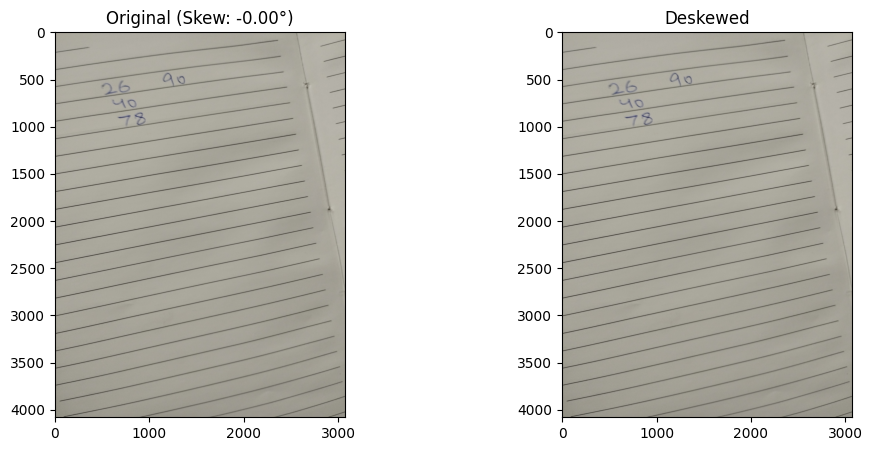

In [6]:
image_path = "/kaggle/input/datasets/mansoor1826/tesst-image/test image.jpg"   

img = cv2.imread(image_path)
if img is None:
    print(f"❌ Image not found at {image_path}. Check the Data tab for the correct path.")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    deskewed_img, angle = deskew(img)
    deskewed_rgb = cv2.cvtColor(deskewed_img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1); plt.imshow(img_rgb); plt.title(f"Original (Skew: {angle:.2f}°)")
    plt.subplot(1,2,2); plt.imshow(deskewed_rgb); plt.title("Deskewed")
    plt.show()

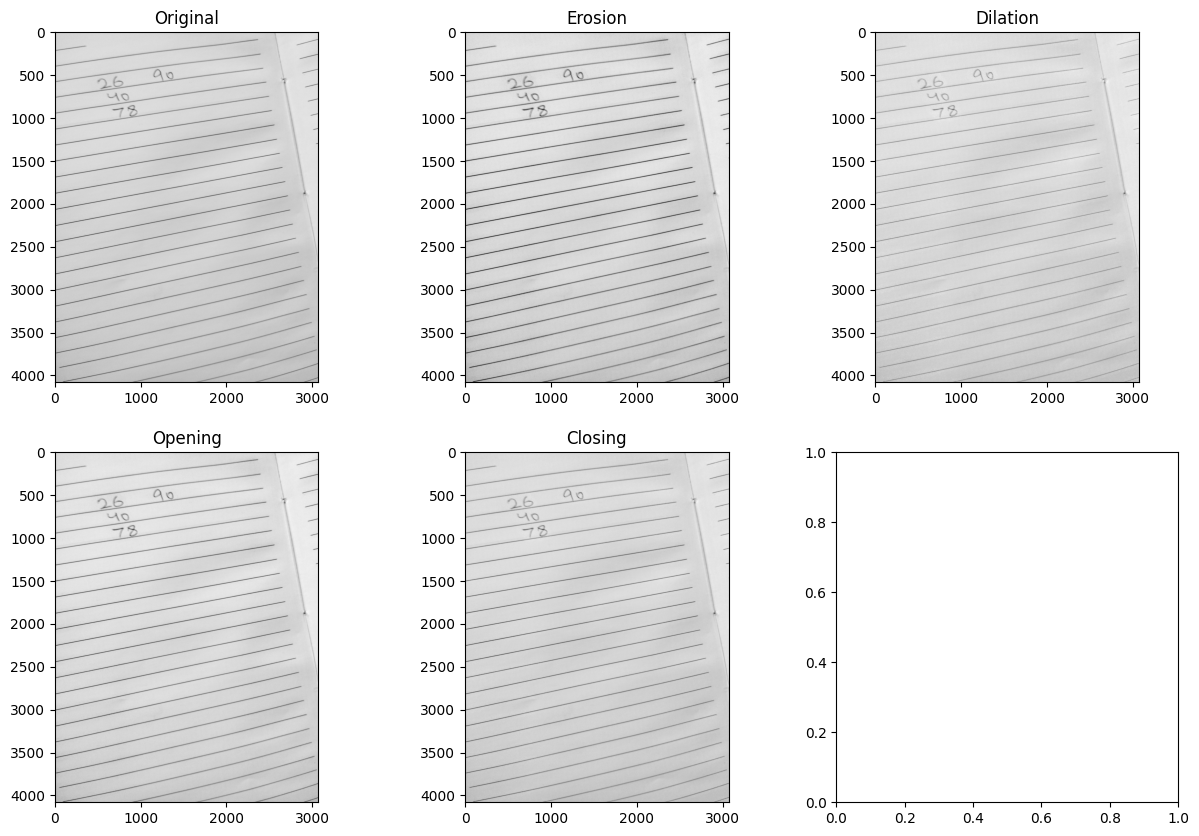

In [7]:
gray = cv2.cvtColor(deskewed_img, cv2.COLOR_BGR2GRAY)
kernel = np.ones((3,3), np.uint8)

erosion = cv2.erode(gray, kernel, iterations=1)
dilation = cv2.dilate(gray, kernel, iterations=1)
opening = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(2,3, figsize=(15,10))
axes[0,0].imshow(gray, cmap='gray'); axes[0,0].set_title('Original')
axes[0,1].imshow(erosion, cmap='gray'); axes[0,1].set_title('Erosion')
axes[0,2].imshow(dilation, cmap='gray'); axes[0,2].set_title('Dilation')
axes[1,0].imshow(opening, cmap='gray'); axes[1,0].set_title('Opening')
axes[1,1].imshow(closing, cmap='gray'); axes[1,1].set_title('Closing')
plt.show()

# Load MNIST dataset

In [8]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(f"Training: {x_train.shape}, Test: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training: (60000, 28, 28), Test: (10000, 28, 28)


# Preprocess MNIST for CNN

In [9]:
from tensorflow.keras import utils

x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_train = utils.to_categorical(y_train, 10)
y_test = utils.to_categorical(y_test, 10)
print("Preprocessing done.")

Preprocessing done.


# Build CNN architecture

In [10]:
from tensorflow.keras import Sequential, layers
model = Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-25 11:26:57.837499: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# Training

In [11]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n🎯 Final Test Accuracy: {test_acc:.4f}")
if test_acc >= 0.98:
    print("🎉 Success! Achieved 98%+ accuracy as required")
else:
    print("❌ Still below 98% – something else is wrong.")

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.7821 - loss: 0.6904 - val_accuracy: 0.9820 - val_loss: 0.0636
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9649 - loss: 0.1209 - val_accuracy: 0.9847 - val_loss: 0.0489
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.9746 - loss: 0.0847 - val_accuracy: 0.9890 - val_loss: 0.0400
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.9797 - loss: 0.0667 - val_accuracy: 0.9890 - val_loss: 0.0362
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.9833 - loss: 0.0561 - val_accuracy: 0.9912 - val_loss: 0.0316
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.9860 - loss: 0.0469 - val_accuracy: 0.9922 - val_loss: 0.0341
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.9866 - loss: 0.0430 - val_accuracy: 0.9910 - val_loss: 0.0330
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9890 - loss: 0.0348 - 

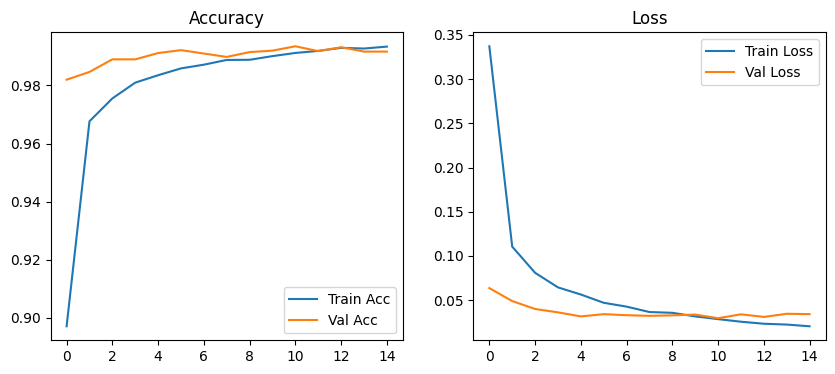

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()